# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name: Fong Yong Sheng



**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [1]:
## Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

# 1. Business Understanding
Goal: The goal of this project is to develop a machine learning regression model that predicts the selling price of a used car based on its characteristics such as brand, model year, mileage, fuel type, engine type, transmission, accident history, and vehicle condition. This solution aims to help buyers and sellers estimate a fair market price, enabling more informed purchasing and selling decisions.

# 2. Data Understanding

## 2.1 Load dataset

In [2]:
## Read *.csv file into pandas DataFrame

df = pd.read_csv("used_cars.csv")

## 2.2 Summary Statistics

In [3]:
## Understand the type of variable for each column

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


In [4]:
## Check for missing data

df.isnull().sum()

brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

In [5]:
## Describe data distribution

# Summary statistics for numerical columns
df.describe()


,model_year
count,4009.000000
mean,2015.515590
std,6.104816
min,1974.000000
25%,2012.000000
50%,2017.000000
75%,2020.000000
max,2024.000000


In [6]:
# Summary statistics for categorical columns

df.describe(include="object")

,brand,model,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
count,4009,4009,4009,3839,4009,4009,4009,4009,3896,3413,4009
unique,57,1898,2818,7,1146,62,319,156,2,1,1569
top,Ford,M3 Base,"110,000 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,A/T,Black,Black,None reported,Yes,"$15,000"
freq,386,30,16,3309,52,1037,905,2025,2910,3413,39


## 2.3 Data Visualization

In [7]:
# Display data types for all columns

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


In [8]:
## Convert mileage and price to numerical data types

# Remove commas and "mi." from mileage, then convert to integer
df["milage"] = (
    df["milage"]
    .str.replace(",", "", regex=False)
    .str.replace(" mi.", "", regex=False)
    .astype(int)
)

# Remove "$" and commas from price, then convert to integer
df["price"] = (
    df["price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(int)
)

# Verify the updated data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   int64 
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   int64 
dtypes: int64(3), object(9)
memory usage: 376.0+ KB


In [9]:
# Replace missing and invalid fuel types with "Unknown"

df["fuel_type"] = (
    df["fuel_type"]
    .fillna("Unknown")
    .replace({
        "-": "Unknown",
        "–": "Unknown"
    })
)

### 2.3.1 Understanding distribution of data

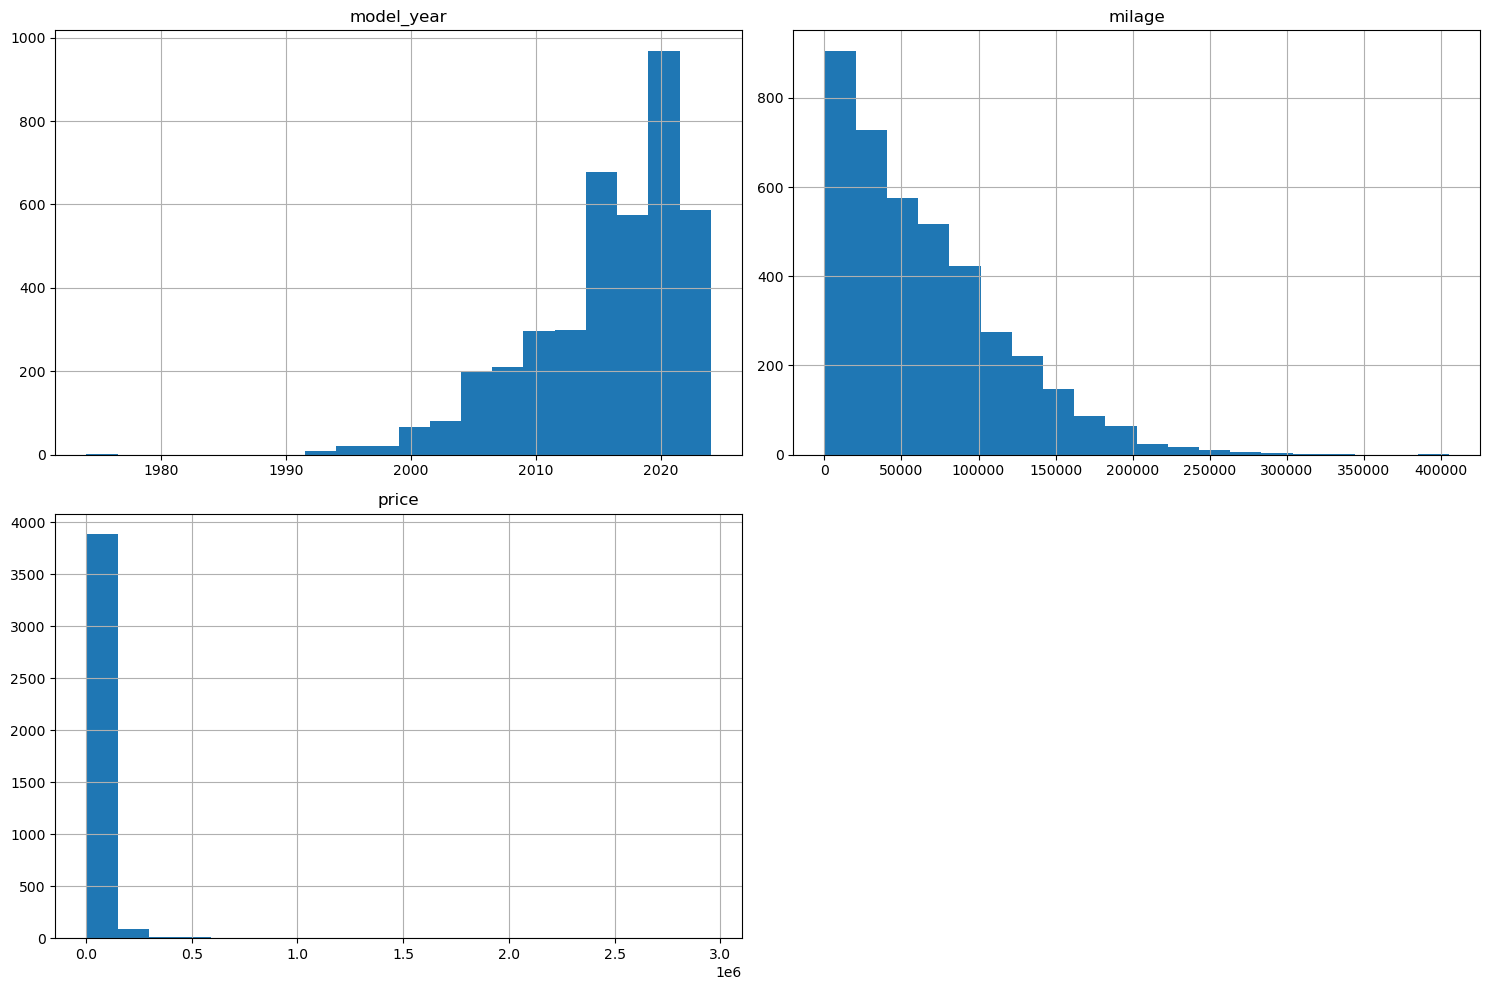

In [10]:
## Understanding distribution of data

# Plot histograms for all numerical columns

df.hist(figsize=(15,10), bins=20)

plt.tight_layout()
plt.show()


- Most vehicles were manufactured between 2015 and 2024, indicating that the dataset mainly consists of relatively newer used cars.

- The price distribution is right-skewed, meaning most used cars are priced in the lower range while only a small number of luxury vehicles have very high prices.

- The mileage distribution is also right-skewed, showing that most vehicles have relatively low mileage, while a few cars have exceptionally high mileage.

### 2.3.1.1 Understanding distribution of target

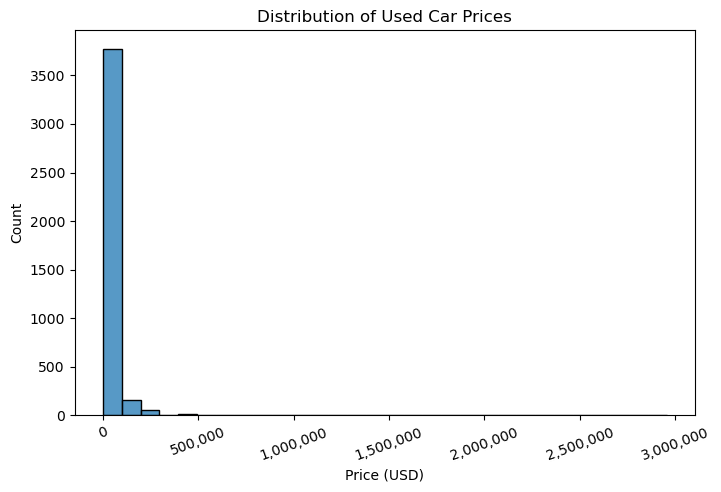

In [11]:
## Understanding distribution of target

# Distribution of target variable (Price)
from matplotlib.ticker import FuncFormatter

# Plot histogram of price
plt.figure(figsize=(8,5))

sns.histplot(df["price"], bins=30)

# Format x-axis with commas
plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{int(x):,}')
)

plt.title("Distribution of Used Car Prices")
plt.xlabel("Price (USD)")
plt.ylabel("Count")

plt.xticks(rotation=20)

plt.show()

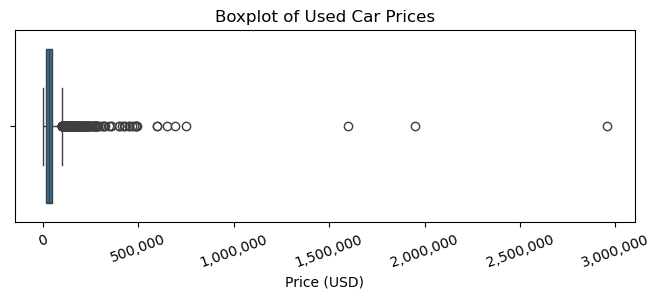

In [12]:
## Visualise price using a boxplot

from matplotlib.ticker import FuncFormatter

# Plot boxplot of price
plt.figure(figsize=(8,2.5))

sns.boxplot(x=df["price"])

# Format x-axis with commas
plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{int(x):,}')
)

plt.title("Boxplot of Used Car Prices")
plt.xlabel("Price (USD)")

plt.xticks(rotation=20)

plt.show()

- The distribution of used car prices is highly right-skewed, with most vehicles priced in the lower range and only a small number of luxury vehicles having very high prices.
- The boxplot reveals several high-price outliers, indicating that a small number of vehicles are sold at exceptionally high prices.

### 2.3.1.2 Understanding distribution of features

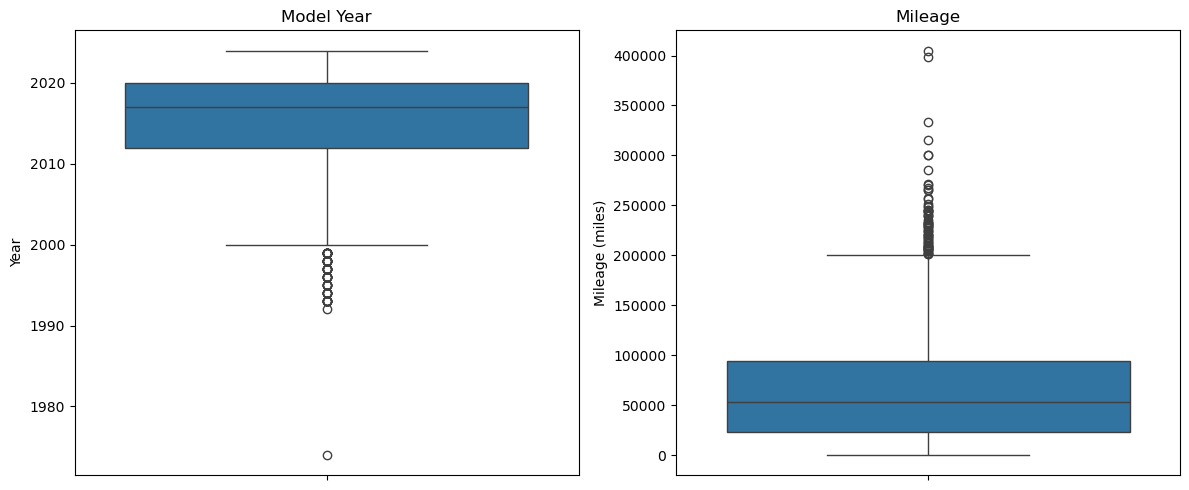

In [13]:
## Understanding distribution of features

## Understanding distribution of numerical features

# Plot boxplots for numerical feature columns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Model Year
sns.boxplot(y=df["model_year"], ax=axes[0])
axes[0].set_title("Model Year")
axes[0].set_ylabel("Year")

# Mileage
sns.boxplot(y=df["milage"], ax=axes[1])
axes[1].set_title("Mileage")
axes[1].set_ylabel("Mileage (miles)")

plt.tight_layout()
plt.show()

- Most vehicles were manufactured between 2012 and 2020, with only a small number of much older vehicles appearing as outliers.
- Most vehicles have relatively low to moderate mileage, while several cars have exceptionally high mileage, indicating the presence of outliers.

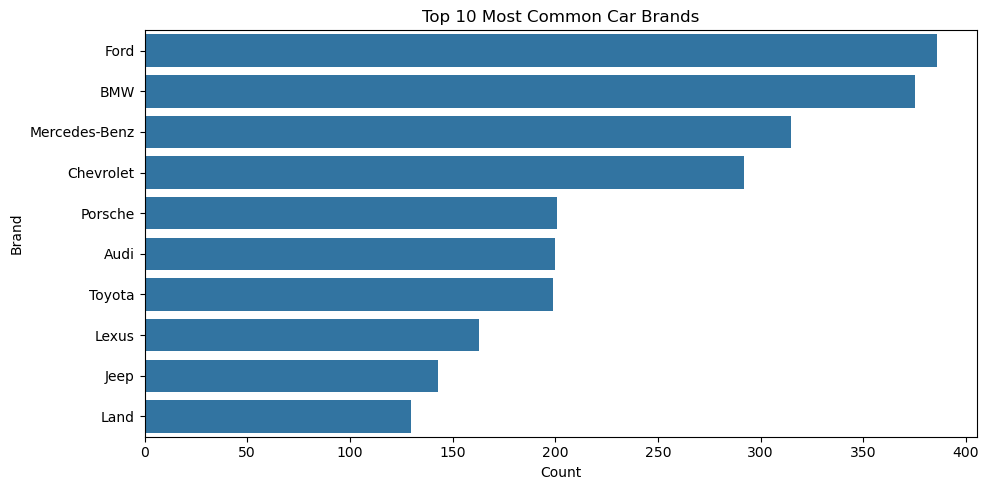

In [14]:
## Understanding distribution of car brands

# Plot the top 10 most common car brands

plt.figure(figsize=(10,5))

sns.countplot(
    y=df["brand"],
    order=df["brand"].value_counts().head(10).index
)

plt.title("Top 10 Most Common Car Brands")
plt.xlabel("Count")
plt.ylabel("Brand")

plt.tight_layout()
plt.show()

- Ford is the most common car brand in the dataset, followed by BMW, Mercedes-Benz, and Chevrolet.
- The dataset contains a mixture of both mass-market and luxury vehicle brands, providing good variety for model training.

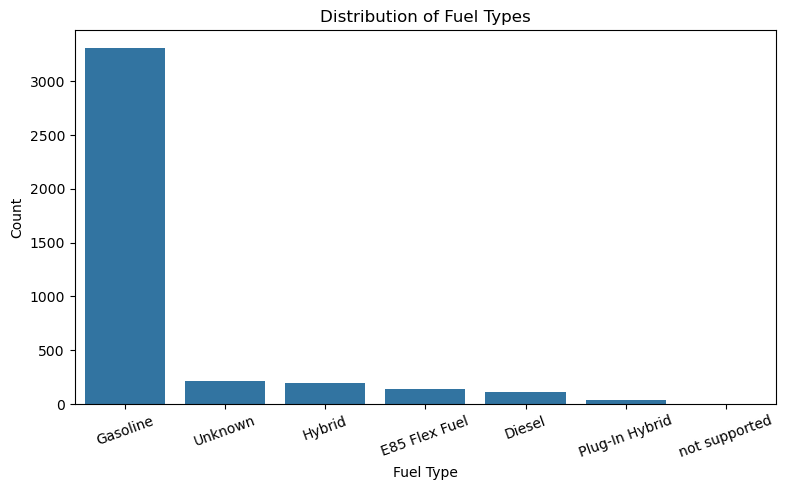

In [15]:
## Understanding distribution of fuel types

plt.figure(figsize=(8,5))

sns.countplot(
    x=df["fuel_type"],
    order=df["fuel_type"].value_counts().index
)

plt.title("Distribution of Fuel Types")
plt.xlabel("Fuel Type")
plt.ylabel("Count")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

- Gasoline is by far the most common fuel type in the dataset.
- Hybrid, diesel, plug-in hybrid, and other fuel types are much less common, indicating an imbalanced distribution of fuel types.

### 2.3.2 Understanding relationship between variables

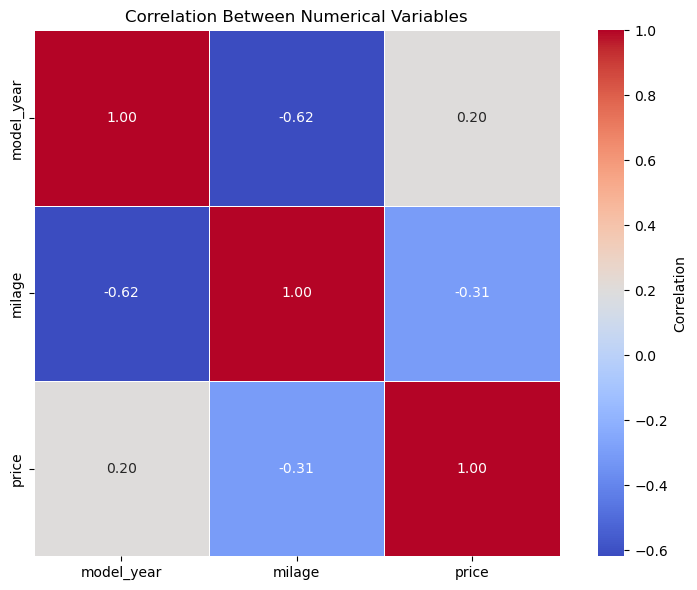

In [16]:
## Understanding relationship between variables

## Understanding relationship between numerical variables

# Plot correlation heatmap for numerical columns

plt.figure(figsize=(8,6))

corr = df[["model_year", "milage", "price"]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Correlation"}
)

plt.title("Correlation Between Numerical Variables")
plt.tight_layout()
plt.show()

- There is a moderate negative correlation (-0.62) between model year and mileage, indicating that newer vehicles generally have lower mileage.
- Price has a weak positive correlation (0.20) with model year, suggesting that newer vehicles tend to be more expensive.
- Price also has a weak negative correlation (-0.31) with mileage, indicating that cars with higher mileage generally have lower prices.

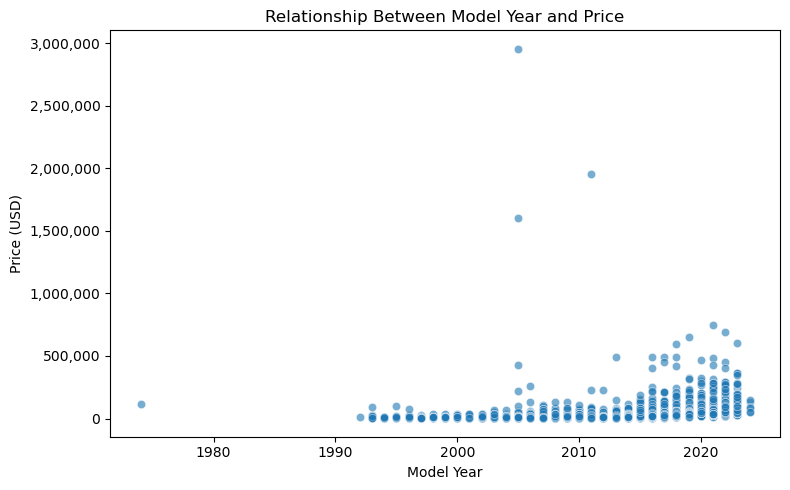

In [17]:
from matplotlib.ticker import StrMethodFormatter

## Understanding relationship between model year and price

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="model_year",
    y="price",
    alpha=0.6
)

plt.title("Relationship Between Model Year and Price")
plt.xlabel("Model Year")
plt.ylabel("Price (USD)")

# Display full price values instead of scientific notation
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

- The scatter plot shows a general upward trend, where newer vehicles tend to have higher prices.
- Although newer cars are generally more expensive, there is considerable variation in price, indicating that other features such as brand, engine, mileage, and transmission also influence the selling price.

# 3. Data Preparation

## 3.1 Data Cleaning

In [18]:
## Clean data

# Display dataset shape
print("Dataset shape:", df.shape)

# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Verify missing values
print("\nMissing values:")
print(df.isnull().sum())

# Verify data types
print("\nData types:")
print(df.dtypes)

Dataset shape: (4009, 12)
Duplicate rows: 0

Missing values:
brand             0
model             0
model_year        0
milage            0
fuel_type         0
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

Data types:
brand           object
model           object
model_year       int64
milage           int64
fuel_type       object
engine          object
transmission    object
ext_col         object
int_col         object
accident        object
clean_title     object
price            int64
dtype: object


## 3.2 Data Transformation

In [19]:
## Data transformation

# Verify numerical columns after transformation
print("Price data type:", df["price"].dtype)
print("Mileage data type:", df["milage"].dtype)

print("\nSample values:")
print(df[["price", "milage"]].head())

Price data type: int64
Mileage data type: int64

Sample values:
   price  milage
0  10300   51000
1  38005   34742
2  54598   22372
3  15500   88900
4  34999    9835


## 3.3 Handle Missing Values

In [20]:
## Handle missing values

# Display missing values before handling
print("Missing values before handling:")
print(df.isnull().sum())

# Display total missing values
print("\nTotal missing values:", df.isnull().sum().sum())

Missing values before handling:
brand             0
model             0
model_year        0
milage            0
fuel_type         0
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

Total missing values: 709


In [21]:
## Investigate missing values

# Display unique values for columns with missing data
print("Fuel Type:")
print(df["fuel_type"].value_counts(dropna=False))

print("\nAccident:")
print(df["accident"].value_counts(dropna=False))

print("\nClean Title:")
print(df["clean_title"].value_counts(dropna=False))

Fuel Type:
fuel_type
Gasoline          3309
Unknown            215
Hybrid             194
E85 Flex Fuel      139
Diesel             116
Plug-In Hybrid      34
not supported        2
Name: count, dtype: int64

Accident:
accident
None reported                             2910
At least 1 accident or damage reported     986
NaN                                        113
Name: count, dtype: int64

Clean Title:
clean_title
Yes    3413
NaN     596
Name: count, dtype: int64


In [22]:
## Fill missing values

# Replace missing fuel type with "Unknown"
df["fuel_type"] = df["fuel_type"].fillna("Unknown")

# Replace missing accident history with "Unknown"
df["accident"] = df["accident"].fillna("Unknown")

# Replace missing clean title with "No"
df["clean_title"] = df["clean_title"].fillna("No")

In [23]:
## Verify missing values after handling

print("Missing values after handling:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

Missing values after handling:
brand           0
model           0
model_year      0
milage          0
fuel_type       0
engine          0
transmission    0
ext_col         0
int_col         0
accident        0
clean_title     0
price           0
dtype: int64

Total missing values: 0


## 3.4 Handle Outliers

In [24]:
## Detect outliers using the IQR method

# Select numerical columns
numerical_cols = ["model_year", "milage", "price"]

for col in numerical_cols:

    # Calculate Q1, Q3 and IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    # Calculate lower and upper bounds
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Detect outliers
    outliers = df[(df[col] < lower) | (df[col] > upper)]

    # Display results
    print(f"{col}")
    print(f"  Number of outliers : {len(outliers)}")
    print(f"  Percentage         : {len(outliers)/len(df)*100:.2f}%\n")

model_year
  Number of outliers : 67
  Percentage         : 1.67%

milage
  Number of outliers : 69
  Percentage         : 1.72%

price
  Number of outliers : 244
  Percentage         : 6.09%



- No outliers were removed.
- The detected outliers represent genuine used cars with extreme prices, mileage, or model years rather than incorrect or impossible data.
- Therefore, all observations were retained for model training.

## 3.5 Feature Engineering

In [25]:
# Display categorical columns

print("Categorical columns:")
print(df.select_dtypes(include="object").columns)

Categorical columns:
Index(['brand', 'model', 'fuel_type', 'engine', 'transmission', 'ext_col',
       'int_col', 'accident', 'clean_title'],
      dtype='object')


In [26]:
## One-Hot Encoding

df = pd.get_dummies(
    df,
    columns=[
        "brand",
        "model",
        "fuel_type",
        "engine",
        "transmission",
        "ext_col",
        "int_col",
        "accident",
        "clean_title"
    ],
    drop_first=True
)

print("One-Hot Encoding completed.")
print("\nDataset shape after encoding:", df.shape)
print("\nData types:")
print(df.dtypes.value_counts())

One-Hot Encoding completed.

Dataset shape after encoding: (4009, 3644)

Data types:
bool     3641
int64       3
Name: count, dtype: int64


## 3.6 Select X and y

In [27]:
## Select features (X) and target (y)

# Features (independent variables)
X = df.drop("price", axis=1)

# Target (dependent variable)
y = df["price"]

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

print("\nNumber of features:", X.shape[1])
print("Target variable:", y.name)

Features (X) shape: (4009, 3643)
Target (y) shape: (4009,)

Number of features: 3643
Target variable: price


## 3.7 Train-Test Split

In [28]:
## Split data into training and testing sets

from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Display the shapes of each dataset
print("Training features (X_train):", X_train.shape)
print("Testing features (X_test):", X_test.shape)
print("Training target (y_train):", y_train.shape)
print("Testing target (y_test):", y_test.shape)

print("\nTrain-Test Ratio: 80% : 20%")
print("Random state:", 42)

Training features (X_train): (3207, 3643)
Testing features (X_test): (802, 3643)
Training target (y_train): (3207,)
Testing target (y_test): (802,)

Train-Test Ratio: 80% : 20%
Random state: 42


## 3.8 Verify Prepared Dataset

In [40]:
## Verify prepared dataset

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

print("\nMissing values in X_train:", X_train.isnull().sum().sum())
print("Missing values in X_test:", X_test.isnull().sum().sum())
print("Missing values in y_train:", y_train.isnull().sum())
print("Missing values in y_test:", y_test.isnull().sum())

print("\nTotal features:", X_train.shape[1])

print("\nDataset is ready for model training.")

Training features: (3207, 3643)
Testing features: (802, 3643)
Training target: (3207,)
Testing target: (802,)

Missing values in X_train: 0
Missing values in X_test: 0
Missing values in y_train: 0
Missing values in y_test: 0

Total features: 3643

Dataset is ready for model training.


# 4. Modelling

### 4.2 Train Model

In [29]:
## Initialise and train model

## Train Linear Regression model

from sklearn.linear_model import LinearRegression

# Create the model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")


Linear Regression model trained successfully.


In [30]:
## Train Decision Tree model

from sklearn.tree import DecisionTreeRegressor

# Create the model
decision_tree_model = DecisionTreeRegressor(random_state=42)

# Train the model
decision_tree_model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [31]:
## Train Random Forest model

from sklearn.ensemble import RandomForestRegressor

# Create the model
random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model
random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [32]:
## Train Gradient Boosting model

from sklearn.ensemble import GradientBoostingRegressor

# Create the model
gradient_boosting_model = GradientBoostingRegressor(
    random_state=42
)

# Train the model
gradient_boosting_model.fit(X_train, y_train)

print("Gradient Boosting model trained successfully.")

Gradient Boosting model trained successfully.


In [33]:
## Predict using trained models

# Linear Regression predictions
lr_predictions = linear_model.predict(X_test)

# Decision Tree predictions
dt_predictions = decision_tree_model.predict(X_test)

# Random Forest predictions
rf_predictions = random_forest_model.predict(X_test)

# Gradient Boosting predictions
gb_predictions = gradient_boosting_model.predict(X_test)

print("Predictions completed successfully.")

Predictions completed successfully.


In [34]:
## Display sample predictions

print("Linear Regression:", lr_predictions[:5])
print("Decision Tree:", dt_predictions[:5])
print("Random Forest:", rf_predictions[:5])
print("Gradient Boosting:", gb_predictions[:5])

Linear Regression: [26742.54046472 15310.33285875 44586.31264535 41415.16696731
 60081.17421035]
Decision Tree: [24000.  8950. 42000. 38500. 21000.]
Random Forest: [31977.73 16106.05 31075.56 35635.03 43233.05]
Gradient Boosting: [39245.76557665 19681.44915262 28660.61603198 45810.81086553
 48501.15356868]


# 5. Model Evaluation

## 5.1 MAE

In [35]:
## Evaluate model

## Calculate Mean Absolute Error (MAE)

from sklearn.metrics import mean_absolute_error

print("Linear Regression MAE:",
      mean_absolute_error(y_test, lr_predictions))

print("Decision Tree MAE:",
      mean_absolute_error(y_test, dt_predictions))

print("Random Forest MAE:",
      mean_absolute_error(y_test, rf_predictions))

print("Gradient Boosting MAE:",
      mean_absolute_error(y_test, gb_predictions))


Linear Regression MAE: 19741.05908024739
Decision Tree MAE: 22720.885286783043
Random Forest MAE: 19230.756596009975
Gradient Boosting MAE: 22672.623399168326


## 5.2 RMSE

In [36]:
## Calculate Root Mean Squared Error (RMSE)

from sklearn.metrics import root_mean_squared_error

print("Linear Regression RMSE:",
      root_mean_squared_error(y_test, lr_predictions))

print("Decision Tree RMSE:",
      root_mean_squared_error(y_test, dt_predictions))

print("Random Forest RMSE:",
      root_mean_squared_error(y_test, rf_predictions))

print("Gradient Boosting RMSE:",
      root_mean_squared_error(y_test, gb_predictions))

Linear Regression RMSE: 138159.2595810291
Decision Tree RMSE: 137396.98160831197
Random Forest RMSE: 134841.18817171222
Gradient Boosting RMSE: 135568.59688786016


## 5.3 R²

In [37]:
## Calculate R² Score

from sklearn.metrics import r2_score

print("Linear Regression R²:",
      r2_score(y_test, lr_predictions))

print("Decision Tree R²:",
      r2_score(y_test, dt_predictions))

print("Random Forest R²:",
      r2_score(y_test, rf_predictions))

print("Gradient Boosting R²:",
      r2_score(y_test, gb_predictions))

Linear Regression R²: 0.0661261450190751
Decision Tree R²: 0.07640280162887392
Random Forest R²: 0.11044385493228981
Gradient Boosting R²: 0.10082044189049588


In [38]:
## New data

## Predict


## Iterative model development


In [39]:
## Further feature engineering / feature selection